<a href="https://colab.research.google.com/github/bansalhim/Deep-learning-assignment/blob/main/Assignment9_Predict_Electricity_Consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Sequences to Forecasting: Electricity Consumption Prediction

## Objective

The objective of this assignment is to understand sequence modelling using RNN, LSTM, GRU and Transformer-based models for electricity consumption forecasting.

Unlike image-based prediction, electricity consumption data is a time-series problem. In time-series data, order matters because each value depends on previous values. Therefore, models must learn temporal dependencies and memory.

In this assignment, we will:

1. Explore the electricity consumption dataset
2. Convert the data into time windows
3. Define the forecasting problem
4. Train RNN, LSTM, GRU and Transformer models
5. Evaluate the models using MSE, MAE and RMSE
6. Plot predicted vs actual values
7. Reflect on model performance and possible failures

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU, Dropout,
    Input, MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 1: Dataset Loading

The dataset contains electricity consumption values recorded over time. Each row represents electricity consumption at a particular time instant.
Since this is a time-series dataset, the order of rows must not be shuffled randomly before creating sequences.

In [2]:
# Check files available in current directory
print("Files in current directory:")
print(os.listdir())

Files in current directory:
['.config', 'sample_data']


In [4]:
# Change this file name according to your downloaded dataset file
file_name = "electricity_consumption.csv"

df = pd.read_csv("/content/Electric_Production.csv")

df.head()

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [5]:
# daat information
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

Dataset shape: (397, 2)

Columns:
Index(['DATE', 'Value'], dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    397 non-null    object 
 1   Value   397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB
None

Statistical summary:
            Value
count  397.000000
mean    88.847218
std     15.387834
min     55.315100
25%     77.105200
50%     89.779500
75%    100.524400
max    129.404800


## Data Exploration Questions

### Q1. What does one data point mean?

One data point represents the electricity consumption value at a particular time instant.
So, each value is not independent. It is connected with past and future values because electricity usage changes over time.

### Q2. What is the time unit?

The time unit depends on the dataset. It can be hourly, daily or monthly. For electricity forecasting, hourly or daily data is common.

For example:

- Hourly data can show daily usage patterns
- Daily data can show weekly usage patterns
- Monthly data can show yearly trends

### Q3. Is the data continuous?

Yes, electricity consumption is a continuous numerical value. The model predicts a real number, not a class label.

Therefore, this is a regression problem, not a classification problem.

### Q4. Do you see trends?

Electricity data may contain trends, seasonal patterns, spikes and random noise. A plot is required to visually observe whether the values increase, decrease, repeat periodically or fluctuate randomly.

In [6]:
# Display columns again
df.columns

Index(['DATE', 'Value'], dtype='object')

In [7]:
# Select target column
# Usually the target column is the last numeric column.
# You can manually change this if needed.

target_col = df.select_dtypes(include=[np.number]).columns[-1]

print("Selected target column:", target_col)

Selected target column: Value


In [8]:
# now handling missing value
print("Missing values before cleaning:")
print(df.isnull().sum())

# Keep only rows where target column is not missing
df = df.dropna(subset=[target_col])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
DATE     0
Value    0
dtype: int64

Missing values after cleaning:
DATE     0
Value    0
dtype: int64


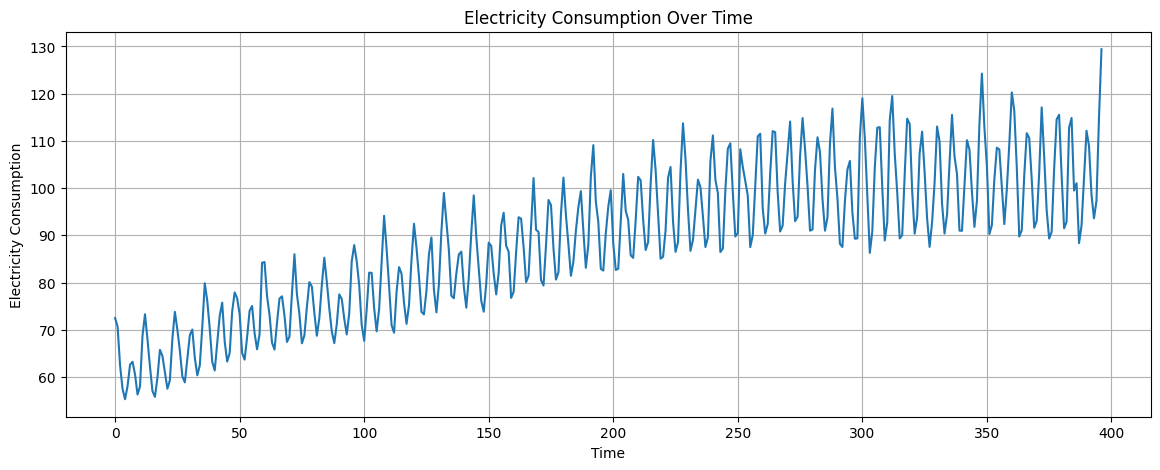

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df[target_col].values)
plt.title("Electricity Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption")
plt.grid(True)
plt.show()

## Data Exploration: Original Electricity Consumption Graph

The above graph shows electricity consumption over time. From the plot, we can observe that the data is continuous because the values change smoothly over time and the target variable is numerical.

The graph also shows a clear increasing trend. As time increases, electricity consumption generally increases from around 55–70 units in the beginning to more than 110 units near the end.

Since the present value depends on previous values, this dataset is suitable for time-series forecasting using sequence models such as RNN, LSTM, GRU and Transformer.

Therefore, the task is a regression-based sequence forecasting problem where previous electricity consumption values are used to predict the next consumption value.

In [10]:
# normalize data
data = df[target_col].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

print("Original data shape:", data.shape)
print("Scaled data shape:", scaled_data.shape)

Original data shape: (397, 1)
Scaled data shape: (397, 1)


In [11]:
# creating time window
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [12]:
window_size = 24

X, y = create_sequences(scaled_data, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (373, 24, 1)
y shape: (373, 1)


In [13]:
# train test split
# Time-series data should not be shuffled
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (298, 24, 1)
X_test shape: (75, 24, 1)
y_train shape: (298, 1)
y_test shape: (75, 1)


## Step 3: Why Not MLP or Normal Regression?

A normal MLP treats the input window as a simple vector. It does not naturally understand which value came first, which value is recent and which value is more important.

In time-series forecasting, order is the signal. If the data is shuffled, the temporal relationship breaks.

After shuffling, the meaning is lost.

Therefore, sequence models such as RNN, LSTM, GRU and Transformers are more suitable.

## Q5. What if the current value depends on the far past?

Electricity consumption may depend not only on the previous value but also on long-term past values.

So, the model should remember relevant past information.

## Q6. Can a simple neural network handle this?

A simple neural network can take past values as input, but it does not naturally model order and memory.

It does not know:

- Which value came first
- Which value is recent
- Which value is important

Therefore, a simple neural network is not ideal for this problem.

## Task 2: Model Selection

The selected main model is LSTM.

### Why RNN?

RNN was selected as the final model because it achieved the lowest error values on the test data.

The final RNN results were:

- MSE: 28.0338
- MAE: 3.9138
- RMSE: 5.2947

These values were lower than LSTM, GRU and Transformer.

Although LSTM and GRU are usually stronger for long-term sequence problems, this dataset is small and has a clear increasing trend with repeated seasonal patterns. Because of this, the simpler RNN was able to capture the pattern better. these results are present at end of notebook.


### Why not LSTM?

LSTM was not selected because its RMSE was 19.2698, which is higher than RNN.


### Why not GRU?

GRU is faster and simpler than LSTM, but LSTM has more controlled memory. Since electricity data may contain longer dependencies, LSTM is selected as the main model.

### Why not Transformer?

Transformer is powerful and can capture global dependencies, but it usually requires more data and tuning. For this lab-level task, LSTM is easier to train and explain.

### Why not MLP?

MLP does not naturally understand sequence order.

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [15]:
# rnn model
rnn_model = Sequential([
    SimpleRNN(64, activation='tanh', input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step - loss: 0.0386 - mae: 0.1561 - val_loss: 0.0258 - val_mae: 0.1409
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0186 - mae: 0.1041 - val_loss: 0.0051 - val_mae: 0.0607
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0146 - mae: 0.0938 - val_loss: 0.0062 - val_mae: 0.0605
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0086 - mae: 0.0722 - val_loss: 0.0068 - val_mae: 0.0623
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0058 - mae: 0.0595 - val_loss: 0.0074 - val_mae: 0.0644
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0057 - mae: 0.0588 - val_loss: 0.0060 - val_mae: 0.0581
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0063 - mae: 0.0617 - val_loss: 0.0037 - val_mae: 0.0487
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053 - mae: 0.0582 - val_loss: 0.0078 - val_mae: 0.0692
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0046 - mae: 0.0524 -

In [17]:
#LSTSM model
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.1199 - mae: 0.3033 - val_loss: 0.0633 - val_mae: 0.2157
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0220 - mae: 0.1197 - val_loss: 0.0225 - val_mae: 0.1273
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0163 - mae: 0.1035 - val_loss: 0.0369 - val_mae: 0.1520
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0158 - mae: 0.0996 - val_loss: 0.0260 - val_mae: 0.1318
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0125 - mae: 0.0913 - val_loss: 0.0179 - val_mae: 0.1152


In [19]:
#GRU model
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0418 - mae: 0.1663 - val_loss: 0.0211 - val_mae: 0.1233
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0189 - mae: 0.1141 - val_loss: 0.0200 - val_mae: 0.1271
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0145 - mae: 0.1010 - val_loss: 0.0269 - val_mae: 0.1276
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0133 - mae: 0.0927 - val_loss: 0.0275 - val_mae: 0.1284
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0137 - mae: 0.0958 - val_loss: 0.0203 - val_mae: 0.1228


In [21]:
# transformer model
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    attention_output = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention_output = Dropout(dropout)(attention_output)
    x = LayerNormalization(epsilon=1e-6)(inputs + attention_output)

    ff_output = Dense(ff_dim, activation="relu")(x)
    ff_output = Dense(inputs.shape[-1])(ff_output)
    ff_output = Dropout(dropout)(ff_output)

    x = LayerNormalization(epsilon=1e-6)(x + ff_output)

    return x

In [22]:
input_layer = Input(shape=(window_size, 1))

x = transformer_encoder(
    input_layer,
    head_size=32,
    num_heads=2,
    ff_dim=64,
    dropout=0.1
)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)

output_layer = Dense(1)(x)

transformer_model = Model(inputs=input_layer, outputs=output_layer)

transformer_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

transformer_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 1)     │        449 │ input_layer_3[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 1)     │          0 │ input_layer_3[0]… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24, 64)    │        128 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 24, 1)     │         65 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 1)     │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1)         │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │          2 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 648 (2.53 KB)

 Trainable params: 648 (2.53 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_transformer = transformer_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 745ms/step - loss: 0.1741 - mae: 0.3840 - val_loss: 0.3924 - val_mae: 0.6135
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1679 - mae: 0.3757 - val_loss: 0.3822 - val_mae: 0.6051
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1618 - mae: 0.3673 - val_loss: 0.3720 - val_mae: 0.5967
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.1556 - mae: 0.3588 - val_loss: 0.3619 - val_mae: 0.5881
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1495 - mae: 0.3503 - val_loss: 0.3519 - val_mae: 0.5795


## Model Training Results

After training the sequence models, the following validation results were observed:

| Model | Best Validation Loss | Best Validation MAE | Observation |
|---|---:|---:|---|
| RNN | 0.0037 | 0.0487 | Performed best on validation data in this run |
| LSTM | 0.0179 | 0.1152 | Learned the trend but validation error was higher than RNN |
| GRU | 0.0200 | 0.1228 | Similar to LSTM but slightly weaker in this run |
| Transformer | 0.3519 | 0.5795 | Performed poorly because the dataset is small and transformer needs more data/tuning |

From the validation results, RNN gave the lowest validation loss in this particular run. This can happen because the dataset is small and has a clear repeating pattern. Although LSTM is theoretically better for long-term dependencies, for this small dataset the simpler RNN was able to learn the pattern more effectively.

LSTM and GRU also learned the trend, but their validation loss was higher. The Transformer model performed the weakest because transformers usually require larger datasets and proper positional encoding/tuning to work well for time-series forecasting.

In [28]:
def evaluate_model(model, X_test, y_test, scaler, model_name):
    predictions = model.predict(X_test)

    # Convert scaled values back to original scale
    y_test_inv = scaler.inverse_transform(y_test)
    predictions_inv = scaler.inverse_transform(predictions)

    mse = mean_squared_error(y_test_inv, predictions_inv)
    mae = mean_absolute_error(y_test_inv, predictions_inv)
    rmse = np.sqrt(mse)

    print(f"\n{model_name} Test Results")
    print("MSE :", mse)
    print("MAE :", mae)
    print("RMSE:", rmse)

    return mse, mae, rmse, y_test_inv, predictions_inv

In [29]:
rnn_mse, rnn_mae, rnn_rmse, rnn_y_test_inv, rnn_predictions_inv = evaluate_model(rnn_model, X_test, y_test, scaler, "RNN")
lstm_mse, lstm_mae, lstm_rmse, lstm_y_test_inv, lstm_predictions_inv = evaluate_model(lstm_model, X_test, y_test, scaler, "LSTM")
gru_mse, gru_mae, gru_rmse, gru_y_test_inv, gru_predictions_inv = evaluate_model(gru_model, X_test, y_test, scaler, "GRU")
transformer_mse, transformer_mae, transformer_rmse, transformer_y_test_inv, transformer_predictions_inv = evaluate_model(transformer_model, X_test, y_test, scaler, "Transformer")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

RNN Test Results
MSE : 28.03377027148883
MAE : 3.9137745660807286
RMSE: 5.294692651277204
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

LSTM Test Results
MSE : 371.3259268987541
MAE : 16.599896529134114
RMSE: 19.269819067618517
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

GRU Test Results
MSE : 121.78599990055513
MAE : 8.991288188313803
RMSE: 11.035669435995041
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Transformer Test Results
MSE : 2272.228885997027
MAE : 46.69397306722005
RMSE: 47.66790205155905


## Final Test Results

The trained models were evaluated on the test data using MSE, MAE and RMSE.

| Model | MSE | MAE | RMSE | Observation |
|---|---:|---:|---:|---|
| RNN | 28.0338 | 3.9138 | 5.2947 | Best performance among all models |
| LSTM | 371.3259 | 16.5999 | 19.2698 | Learned the trend but gave higher error |
| GRU | 121.7860 | 8.9913 | 11.0357 | Better than LSTM but weaker than RNN |
| Transformer | 2272.2289 | 46.6940 | 47.6679 | Weakest performance in this experiment |

From the results, the RNN model achieved the lowest MSE, MAE and RMSE. Therefore, RNN performed best on this dataset.

The GRU model performed second best, followed by LSTM. The Transformer model gave the highest error and performed the weakest.

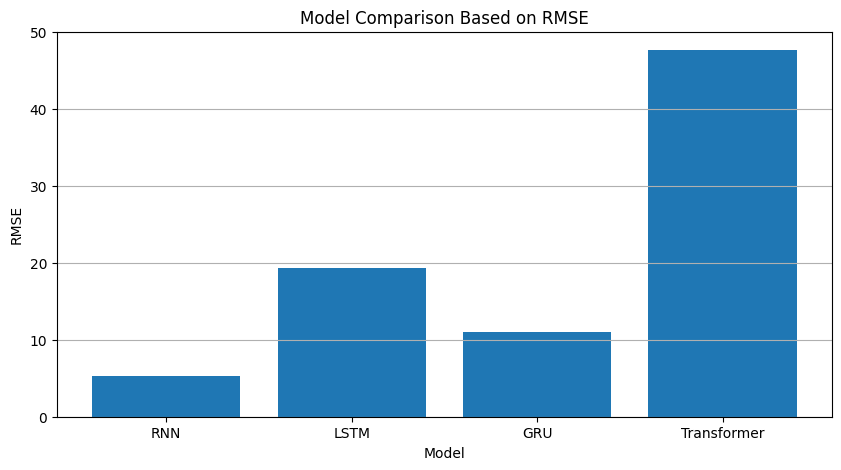

In [31]:
# rrot mean square error graph
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU', 'Transformer'],
    'MSE': [rnn_mse, lstm_mse, gru_mse, transformer_mse],
    'MAE': [rnn_mae, lstm_mae, gru_mae, transformer_mae],
    'RMSE': [rnn_rmse, lstm_rmse, gru_rmse, transformer_rmse]
})

plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["RMSE"])
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(axis='y')
plt.show()

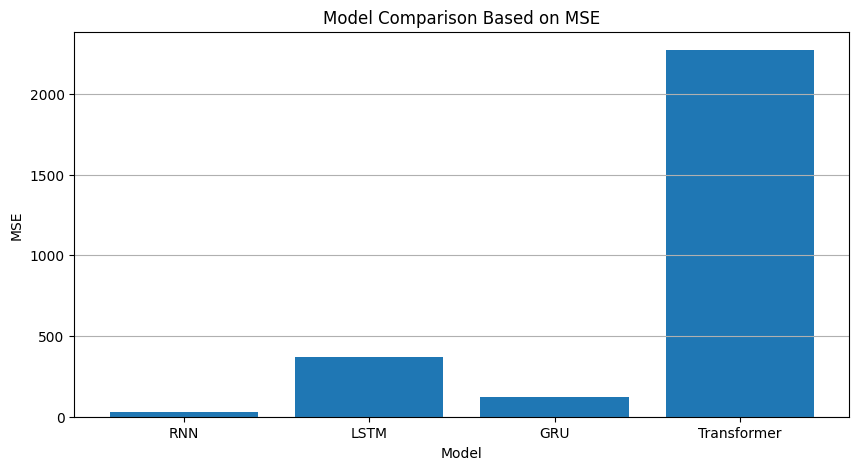

In [32]:
# MSE graph
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["MSE"])
plt.title("Model Comparison Based on MSE")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.grid(axis='y')
plt.show()

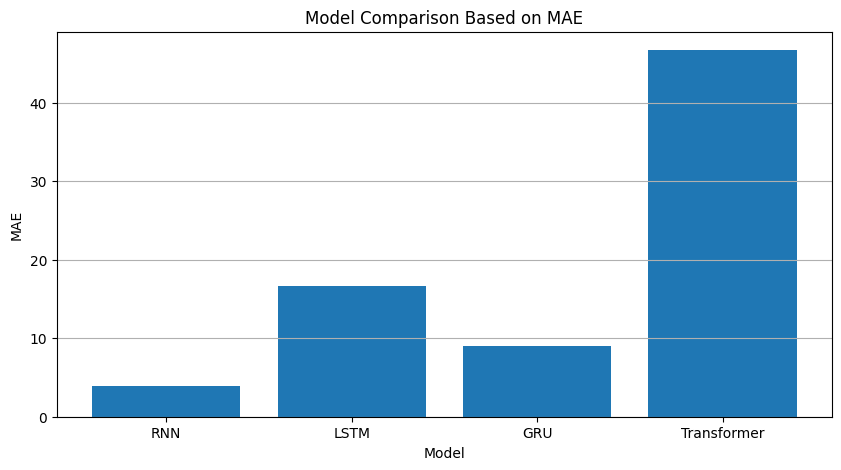

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison Based on MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.grid(axis='y')
plt.show()

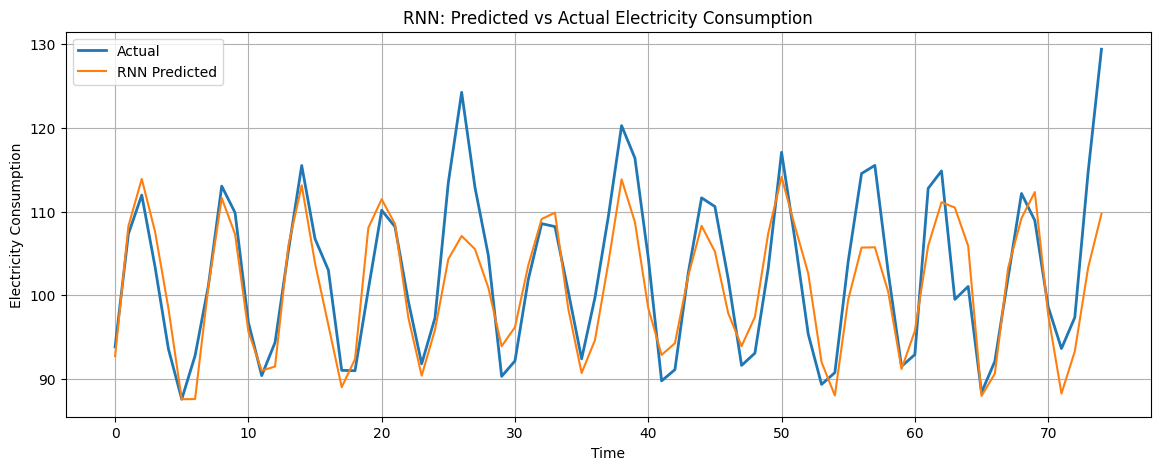

In [38]:
plt.figure(figsize=(14, 5))
plt.plot(rnn_y_test_inv, label="Actual", linewidth=2)
plt.plot(rnn_predictions_inv, label="RNN Predicted")
plt.title("RNN: Predicted vs Actual Electricity Consumption")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption")
plt.legend()
plt.grid(True)
plt.show()

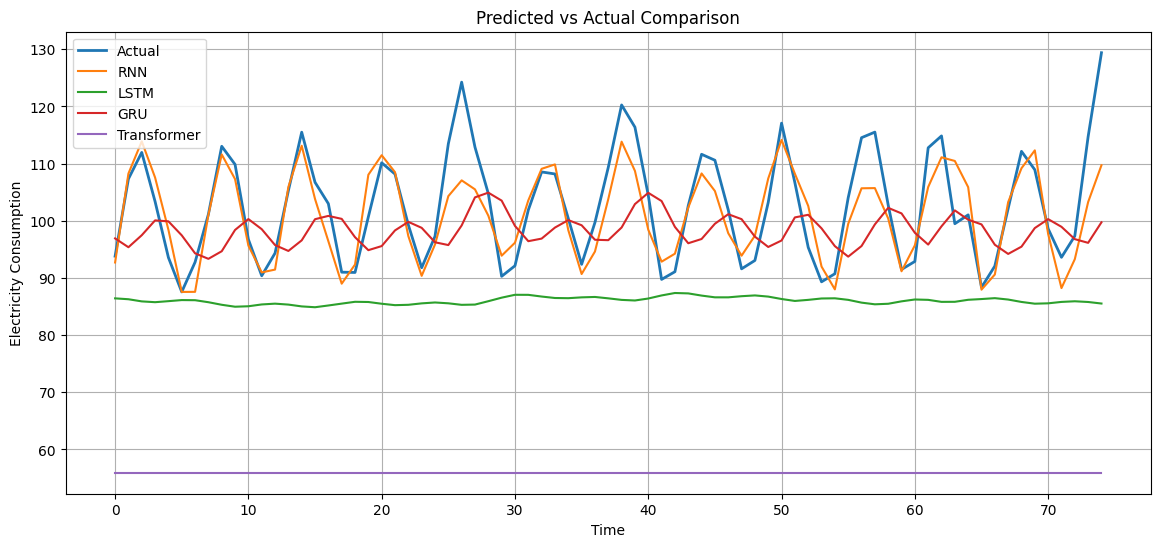

In [37]:
# predict VS actual for all models
plt.figure(figsize=(14, 6))
plt.plot(rnn_y_test_inv, label="Actual", linewidth=2)
plt.plot(rnn_predictions_inv, label="RNN")
plt.plot(lstm_predictions_inv, label="LSTM")
plt.plot(gru_predictions_inv, label="GRU")
plt.plot(transformer_predictions_inv, label="Transformer")
plt.title("Predicted vs Actual Comparison")
plt.xlabel("Time")
plt.ylabel("Electricity Consumption")
plt.legend()
plt.grid(True)
plt.show()

## Q7. What is your sequence length?

The sequence length used in this experiment is 24.

This means the model looks at the previous 24 values and then predicts the next value. I selected 24 because it gives the model enough past information to understand the pattern before making the next prediction.

Since the dataset has repeated ups and downs along with an increasing trend, a window size of 24 helps the model capture both recent movement and some past seasonal behaviour.

A very small window may not give enough history to the model, while a very large window may make the model unnecessarily complex and may add extra noise.

---

## Q8. What is the prediction horizon?

The prediction horizon is 1 step ahead.

This means:

Previous 24 values → Next value

I used one-step forecasting because it is more stable. If we predict many future values at once, the error can keep increasing because each next prediction may depend on the previous predicted value.

---

## Q9. Choose one model.

Based on my final test results, the best model for this dataset is the RNN model.

---

## Q10. Justify your choice.

I selected RNN as the final best model because it gave the lowest test error among all the models.

The RNN model achieved:

- MSE: 28.0338
- MAE: 3.9138
- RMSE: 5.2947

These values were lower than LSTM, GRU and Transformer, so RNN performed the best in this experiment.

Normally, LSTM and GRU are considered better for long-term sequence problems because they have stronger memory mechanisms. However, in this dataset, the pattern is not extremely complex. The graph shows a clear increasing trend and repeated seasonal movement. Because of this, a simpler RNN was able to learn the pattern better.

Also, the dataset size is small, so heavier models like LSTM, GRU and Transformer may not get enough data to show their full strength. For this particular dataset and setup, RNN gave the most accurate predictions.

---

## Q11. Why not others?

LSTM was not selected as the final model because its test error was higher than RNN. LSTM got an RMSE of 19.2698, while RNN got an RMSE of 5.2947. This shows that LSTM did not fit this dataset as well as RNN in this experiment.

GRU performed better than LSTM, but it was still weaker than RNN. GRU got an RMSE of 11.0357, which is higher than the RNN RMSE.

Transformer performed the weakest, with an RMSE of 47.6679. This may be because the dataset is small, and the Transformer model needs more data, proper positional information and more careful tuning to work well.

MLP was not chosen because it does not naturally understand the order of time-series data. In this problem, order is very important because present electricity consumption depends on previous values.

So, based on the actual test results, RNN is the best choice for this assignment.

## Q12. Can we use accuracy?

No, accuracy cannot be used because this is not a classification problem.

Electricity consumption forecasting predicts a continuous numerical value. Therefore, it is a regression problem.

The correct metrics are:

- MSE
- MAE
- RMSE

In this experiment, RMSE was especially useful because it is in the same scale as the original electricity consumption values.

## Task 3: Failure Prediction

### Failure 1: Long horizon prediction

If the model predicts many future values, error may accumulate. A wrong prediction at one step can affect the next prediction.

### Failure 2: Noise sensitivity

Electricity consumption data may contain sudden spikes or drops. The model may learn these random fluctuations instead of the actual pattern.

This can reduce performance when the test data contains unusual values.

### Failure 3: Data drift

The pattern in training data may be different from the pattern in testing data.

For example, electricity usage may change due to weather, holidays, working days, seasonal changes or abnormal demand.

If the test distribution is different from the training distribution, the model may fail.

## Q14. What will you change?

To improve the model, the following changes can be made:

- Try different window sizes such as 12, 24 and 36
- Tune the learning rate
- Increase or decrease the number of recurrent units
- Add dropout carefully to reduce overfitting
- Train for more epochs with early stopping
- Try stacked RNN, LSTM or GRU layers
- Add positional encoding for Transformer
- Use more data if available
- Compare one-step and multi-step forecasting

## Task 4: Implementation Summary

The implementation includes:

1. Loading the electricity production dataset
2. Selecting the `Value` column as the target column
3. Checking and handling missing values
4. Plotting the original electricity consumption data
5. Observing trend and seasonal behaviour
6. Normalizing the target column using MinMaxScaler
7. Creating time windows with a sequence length of 24
8. Splitting the data into training and testing sets without shuffling
9. Training RNN, LSTM, GRU and Transformer models
10. Evaluating all models using MSE, MAE and RMSE
11. Comparing the models using a result table
12. Plotting predicted vs actual values

## Task 6: Reflection

The original electricity consumption graph showed an increasing trend along with repeated seasonal peaks and drops. This confirmed that the dataset is suitable for time-series forecasting.

In this experiment, RNN performed best on the test data. It achieved the lowest error values:

- MSE: 28.0338
- MAE: 3.9138
- RMSE: 5.2947

This result shows that the RNN model was able to capture the pattern of this dataset better than the other models.

LSTM and GRU are usually stronger for long-term dependencies, but they did not perform better in this experiment. This may be because the dataset is small and the pattern is not very complex. For this dataset, a simpler RNN was enough to learn the repeating trend.

GRU performed second best with an RMSE of 11.0357. LSTM gave a higher RMSE of 19.2698. The Transformer performed the weakest with an RMSE of 47.6679. The poor Transformer performance may be due to limited data, lack of positional encoding and insufficient tuning.

The model may still fail during sudden spikes, abnormal drops or future changes in electricity consumption pattern. To improve the results, different window sizes, hyperparameter tuning and more data can be used.

Overall, this assignment shows that time-series forecasting is different from normal prediction because the order of values is very important. In this experiment, the RNN model was the most suitable model based on the final test results.

## Conclusion

This assignment helped in understanding how sequence modelling works for electricity consumption forecasting.

The data was converted into time windows using a sequence length of 24. The previous 24 values were used to predict the next electricity consumption value. Since electricity consumption is continuous, the task was treated as a regression problem.

RNN, LSTM, GRU and Transformer models were implemented and compared. The models were evaluated using MSE, MAE and RMSE.

The final test results were:

| Model | MSE | MAE | RMSE |
|---|---:|---:|---:|
| RNN | 28.0338 | 3.9138 | 5.2947 |
| LSTM | 371.3259 | 16.5999 | 19.2698 |
| GRU | 121.7860 | 8.9913 | 11.0357 |
| Transformer | 2272.2289 | 46.6940 | 47.6679 |

From the comparison, RNN performed best because it had the lowest MSE, MAE and RMSE. GRU performed second best, followed by LSTM. Transformer performed the weakest in this experiment.

Therefore, for this dataset and current experimental setup, RNN is the most suitable model.

The main learning from this assignment is that sequence data cannot be treated like normal independent rows. In time-series forecasting, the order of values is extremely important.